# Ordinary Differential Equations (ODEs)

An [ordinary differential equation](https://en.wikipedia.org/wiki/Ordinary_differential_equation) is a differential equation with a single independent variable. There are many different methods to solve ODEs numerically, depending on the problem. These problems are very common across physics, chemistry, mathematics, etc. 

Over the next few weeks, we will discuss how to solve various types of ODES including:
+ Initial value problems (IVPS)
+ Boundary value problems (BVPs)
+ Eigenvalue problems
+ Systems of ODEs
+ Higher order differential equations

## First-Order Differential Equations
The general form of a 1st-order differential equation in one variable:
$$ \frac{dx}{dt} = f(x,t),$$

where $t$ is the independent variable. In order to solve for $x(t)$, we require knowledge of a value of $x$ defined at some $t$.

If, for example, we are solving for the time evolution of $x(t)$, and we have $x(0)$, then this is known as an **initial value problem** (IVP).

### Euler's Method
Taylor expansion about $t$, by some small $h$:

$$x(t + h) = x(t) + h \frac{dx}{dt} + \frac{1}{2} h^2 \frac{d^2 x}{dt^2} + \dots \\ 
= x(t) + h f(x,t) + O(h^2)$$

Gives a first order solution for $x$ at some next time $t_1 = t_0 + h$. 

Thus, we can iteratively step forward in time, $t_{i+1} = t_i + h$, wherein $h = \Delta t = t_{i+1} - t_i$, is our *timestep* such that:

$$ x_{i+1} = x_i + \Delta t f_i. = x_i + \Delta t \frac{dx_i}{dt}$$ 

Effectively, Euler's method uses the slope of a function at some given time to predict the value of the function at some later time. 
You can imagine, that for functions with a lot of variation, in which the slope changes quickly, taking too large of a timestep become inaccurate quickly!

:question
```{embed} ex_6-1
```

```{embed} sol_6-1
```




<h2><span class="fa fa-flash"></span> In-Class Coding Exercise </h2>

```{embed} icc_6-1
```

### Runge-Kutta
Using more (smaller) timesteps, allows us to get more accurate estimates of the next value of $x_{i+1}$ as the slope we are using to predict the new value of our function is most accurate for small $h$. 

Thus, the more representative our slope is, the more accurate we should be able to get! 

For Runge-Kutta, we apply this concept by splitting the interval between $t = t$ and $t=t+h$ and using the slope at $t=t+h/2$ to extrapolate x(t) to x(t+h). This way, for the same step in $h$, we get a much more accurate extrapolation.

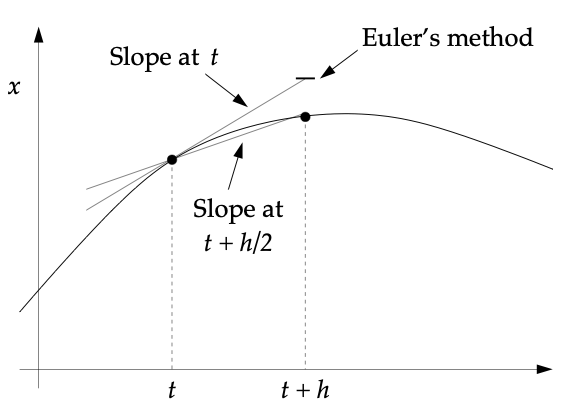

```{tip} Second-Order Scheme
:class: dropdown

You can think of as the analogous to the improvement we get from Simpson's method, compared to Trapezoid rule, from our [numerical integration chapter](./4a_integrals.ipynb). 

```

However, since the ODE is a function of both $x$ and $t$, we need to be able to extrapolate first to find the value of the half-step.

#### 2nd Order Runge-Kutta
So, we define the slope at the start of our interval $t_i$:
$$k_1 = h f(x_i,t_i) = h f_i $$
Use it to extrapolate the slope at the half interval:
$$k_2 = h f(x_{i/2}, t_{i/2}) = h f(x+k_1/2, t+h/2) $$
And plug it in to solve at the end of the interval $t_{i+1} = t_i + h$:
$$ x(t_{i+1}) = x_{i+1} = x_{i} + k_2$$

We can see that an RK2 method, is just forward Euler modified by a half-step. 

$k_1$ and $k_2$ are our RK coefficients. 


<h2><span class="fa fa-flash"></span> In-Class Coding Exercise </h2>

```{embed} icc_6-2
```

#### 4th order Runge-Kutta
In principle, you can keep splitting the interval into multiple sub-steps, thereby increasing the order of the calculation. A fourth order Runge-Kutta (RK4) is typically the most common and widely used Runge-Kutta implementation: a good mix of accuracy and a reasonable number of coefficients to compute. 

$$ k_{1} = h f(x_i, t_i) \\ 
k_{2} = h f\left(x_i + \frac{1}{2} k_{1}, t_i + \frac{1}{2} h\right) \\ 
k_{3} = h f\left(x_i + \frac{1}{2} k_{2}, t_i + \frac{1}{2} h\right) \\ 
k_{4} = h f\left(x_i + k_{3}, t_i + h\right) \\ 
x(t_{i+1}) = x(t_i) + \frac{1}{6} (k_{1} + 2 k_{2} + 2 k_{3} + k_{4})$$

<h2><span class="fa fa-flash"></span> In-Class Coding Exercise </h2>

```{embed} icc_6-3
```

## Systems of 1st Order ODEs

In the case that we have a system of 1st order ODES for different dependent variables of the same independent variable:
$$\frac{dx}{dt} = f_{x}(x, y, t); \ \  \frac{dy}{dt} = f_{y}(x, y, t)$$

We can recast them into a vector form, where ${\bf r} = (x,y)$ such that:

$$\frac{d{\bf r}}{dt} = {\bf f}({\bf r}, t)$$

From here, you can see that the Taylor expansion is equivalent to the 1D case:

$${\bf r}(t + h) = r(t) + h \frac{d{\bf r}}{dt} + O(h^2)$$

So we can reproduce the same expressions for Euler's method and Runge-Kutta, with scalar variables replaced by vectors.